# MTL-GRU — 4-task full-200 SOH-weight sweep

This notebook is derived from the previous **MTL-GRU 4-task full-200** notebook.  
The backbone, data handling, masks, scaler inversion, optimizer, five seeds, and 200-epoch protocol are kept unchanged.

## What changes in this experiment

Only the **task-level loss weights** are changed.

The three new candidate settings are:

| config | SOH | R0 | R1 | R2 |
|---|---:|---:|---:|---:|
| `soh40` | 0.40 | 0.20 | 0.20 | 0.20 |
| `soh50` | 0.50 | 1/6 | 1/6 | 1/6 |
| `soh60` | 0.60 | 0.40/3 | 0.40/3 | 0.40/3 |

The old equal-weight `0.25 / 0.25 / 0.25 / 0.25` run is **not retrained by default**. Its frozen validation losses at the joint-best checkpoint are embedded below and are used only as a validation reference.

## Important methodological rule

This notebook is intentionally split into two stages.

### Stage A — weight sweep, validation only
1. Train every candidate for the full 200 epochs and all five seeds.
2. Use the **same weights** for:
   - the training objective;
   - the validation joint loss;
   - the primary joint-best checkpoint selection.
3. Compare candidate weights using **validation data only**.
4. Do **not** inspect test performance for every candidate.

### Stage B — final test
After one weight setting has been fixed from Stage A, set `FINAL_CONFIG` to that config name and run the final evaluation cells.  
Only that frozen config is evaluated on test.

R0/R1/R2 still average their three SOC channels equally inside each task.  
The task-weight sweep therefore changes only the balance among SOH/R0/R1/R2.

In [1]:
import sys
import torch
import numpy as np
import pandas as pd

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Python: d:\venvs\torch_test\Scripts\python.exe
PyTorch: 2.8.0+cpu
NumPy: 2.5.3
Pandas: 3.0.5


In [2]:
from pathlib import Path
import json, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEEDS = [42, 43, 44, 45, 46]
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)
print('seeds:', SEEDS)

# Keep the original full-200 backbone / hyperparameters unchanged.
HID          = 64
ENC_LAYERS   = 1
DROPOUT      = 0.2
LR           = 3e-3
WEIGHT_DECAY = 1e-4
EPOCHS       = 200
BATCH_SIZE   = 32
TRAIN_EVAL_BATCH = 256

# ------------------------------------------------------------
# Stage control
# ------------------------------------------------------------
# First pass:
#   RUN_SWEEP = True
#   FINAL_CONFIG = None
#
# After the validation-only weight decision:
#   RUN_SWEEP = False
#   FINAL_CONFIG = 'soh40' / 'soh50' / 'soh60'
#
# With RUN_SWEEP=False, the notebook reloads the saved sweep CSVs and
# does not retrain. Final evaluation then loads the saved checkpoints.
RUN_SWEEP = False
FINAL_CONFIG = 'soh50'  # frozen after validation-only weight selection

TASK_ORDER = ['SOH', 'R0', 'R1', 'R2']

WEIGHT_CONFIGS = {
    'soh40': {'SOH': 0.40, 'R0': 0.20,       'R1': 0.20,       'R2': 0.20},
    'soh50': {'SOH': 0.50, 'R0': 1.0 / 6.0,  'R1': 1.0 / 6.0,  'R2': 1.0 / 6.0},
    'soh60': {'SOH': 0.60, 'R0': 0.40 / 3.0, 'R1': 0.40 / 3.0, 'R2': 0.40 / 3.0},
}

for name, w in WEIGHT_CONFIGS.items():
    assert list(w.keys()) == TASK_ORDER
    assert all(v > 0 for v in w.values())
    assert abs(sum(w.values()) - 1.0) < 1e-12
    print(name, {k: round(v, 6) for k, v in w.items()})

SWEEP_PREFIX = 'mtl_gru_4task_full200_weight_sweep'  # kept for output naming only
CKPT_ROOT = Path('.')  # SOH50 folder is the notebook working directory
CKPT_ROOT.mkdir(parents=True, exist_ok=True)

device: cpu
seeds: [42, 43, 44, 45, 46]
soh40 {'SOH': 0.4, 'R0': 0.2, 'R1': 0.2, 'R2': 0.2}
soh50 {'SOH': 0.5, 'R0': 0.166667, 'R1': 0.166667, 'R2': 0.166667}
soh60 {'SOH': 0.6, 'R0': 0.133333, 'R1': 0.133333, 'R2': 0.133333}


In [3]:
# ---- load data + scaler ----
DATA_CANDIDATES   = [Path('seq_dataset_10dim_v7.npz'), Path('/mnt/data/seq_dataset_10dim_v7.npz')]
SCALER_CANDIDATES = [Path('scaler_10dim_v7.json'),     Path('/mnt/data/scaler_10dim_v7.json')]
DATA_PATH   = next((p for p in DATA_CANDIDATES if p.exists()), None)
SCALER_PATH = next((p for p in SCALER_CANDIDATES if p.exists()), None)

if DATA_PATH is None or SCALER_PATH is None:
    raise FileNotFoundError(
        '请把 seq_dataset_10dim_v7.npz 和 scaler_10dim_v7.json 放到同目录或 /mnt/data/。'
    )

data = np.load(DATA_PATH, allow_pickle=True)
features = data['features'].tolist()
F = len(features)

cfg = json.load(open(SCALER_PATH, encoding='utf-8'))
assert cfg['features'] == features, 'scaler 与数据集特征顺序不一致'
assert bool(cfg.get('log_r', False)), '当前 MTL 物理还原要求 scaler 中 log_r=True'

MEAN = np.asarray(cfg['mean'], dtype=float)
STD  = np.asarray(cfg['std'], dtype=float)
R_COLS = set(cfg['r_cols'])

# ---- four-task definition: 1 + 3 + 3 + 3 = 10 output channels ----
TASK_CHANNELS = {
    'SOH': [features.index('SOH')],
    'R0':  [features.index('SOC10_R0'), features.index('SOC50_R0'), features.index('SOC90_R0')],
    'R1':  [features.index('SOC10_R1'), features.index('SOC50_R1'), features.index('SOC90_R1')],
    'R2':  [features.index('SOC10_R2'), features.index('SOC50_R2'), features.index('SOC90_R2')],
}
TASK_DIMS = {task: len(idxs) for task, idxs in TASK_CHANNELS.items()}

assert list(TASK_CHANNELS.keys()) == TASK_ORDER
assert sum(TASK_DIMS.values()) == F == 10
assert set(sum(TASK_CHANNELS.values(), [])) == set(range(F))

FEATURE_TO_TASK = {
    features[j]: task
    for task, idxs in TASK_CHANNELS.items()
    for j in idxs
}

def inverse_feature(z, feature_idx):
    """Inverse standardized feature to its physical/original scale."""
    x = np.asarray(z, dtype=float) * STD[feature_idx] + MEAN[feature_idx]
    if features[feature_idx] in R_COLS:
        return np.expm1(x)        # preprocessing confirmed: log1p(R)
    return x                      # SOH: affine inverse only

def get(split):
    # Keep exactly the same input handling as the previous STL/MTL notebooks.
    X = np.where(
        data[f'{split}_X_fmask'].astype(bool),
        data[f'{split}_X'].astype(np.float32),
        0.0
    )
    Xt = data[f'{split}_X_tmask'].astype(bool)

    Y = data[f'{split}_Y'].astype(np.float32)
    Ym = data[f'{split}_Y_mask'].astype(bool)
    bid = data[f'{split}_bid']
    return X.astype(np.float32), Xt, Y, Ym, bid

Xtr, Xttr, Ytr, Ymtr, btr = get('train')
Xva, Xtva, Yva, Ymva, bva = get('val')
Xte, Xtte, Yte, Ymte, bte = get('test')
HORIZON = Ytr.shape[1]

utr, uva, ute = np.unique(btr), np.unique(bva), np.unique(bte)

print('features:', features)
print('task channels:', {k: [features[j] for j in v] for k, v in TASK_CHANNELS.items()})
print('sample/window counts:',
      'train=', len(btr), 'val=', len(bva), 'test=', len(bte))
print('unique battery counts:',
      'train=', len(utr), 'val=', len(uva), 'test=', len(ute))
print('max forecast horizon:', HORIZON)

assert np.intersect1d(utr, uva).size == 0, 'Leakage: train and val share battery IDs'
assert np.intersect1d(utr, ute).size == 0, 'Leakage: train and test share battery IDs'
assert np.intersect1d(uva, ute).size == 0, 'Leakage: val and test share battery IDs'

print('Battery leakage check passed.')

# ---------------------------------------------------------------------
# Frozen equal-weight MTL validation reference
# ---------------------------------------------------------------------
# These are the per-seed validation task MSEs at the joint-best checkpoint
# from the already-completed equal-weight full-200 run.
#
# They are VALIDATION values only. No frozen test metric is used below to
# choose a task-weight configuration.
FROZEN_EQUAL_VAL_BY_SEED = pd.DataFrame([
    {'seed': 42, 'SOH': 0.044011447364830175, 'R0': 0.38749302528035656, 'R1': 0.3070050019848068,  'R2': 0.3136505149961217},
    {'seed': 43, 'SOH': 0.04018367813433045,  'R0': 0.33929897378719653, 'R1': 0.29926744210128337, 'R2': 0.31680448833390323},
    {'seed': 44, 'SOH': 0.04710041864400904,  'R0': 0.40884126755478184, 'R1': 0.2970211384537325,  'R2': 0.294179553984624},
    {'seed': 45, 'SOH': 0.035052699985100785, 'R0': 0.46350110767197994, 'R1': 0.31049362628576976, 'R2': 0.27787299386184455},
    {'seed': 46, 'SOH': 0.048972507257836105, 'R0': 0.40756932018562114, 'R1': 0.334191896256697,   'R2': 0.3237714969077709},
])

assert FROZEN_EQUAL_VAL_BY_SEED['seed'].tolist() == SEEDS
display(FROZEN_EQUAL_VAL_BY_SEED.round(6))

features: ['SOH', 'SOC10_R0', 'SOC50_R0', 'SOC90_R0', 'SOC10_R1', 'SOC50_R1', 'SOC90_R1', 'SOC10_R2', 'SOC50_R2', 'SOC90_R2']
task channels: {'SOH': ['SOH'], 'R0': ['SOC10_R0', 'SOC50_R0', 'SOC90_R0'], 'R1': ['SOC10_R1', 'SOC50_R1', 'SOC90_R1'], 'R2': ['SOC10_R2', 'SOC50_R2', 'SOC90_R2']}
sample/window counts: train= 4581 val= 45 test= 45
unique battery counts: train= 212 val= 45 test= 45
max forecast horizon: 29
Battery leakage check passed.


,seed,SOH,R0,R1,R2
0,42,0.044011,0.387493,0.307005,0.313651
1,43,0.040184,0.339299,0.299267,0.316804
2,44,0.047100,0.408841,0.297021,0.294180
3,45,0.035053,0.463501,0.310494,0.277873
4,46,0.048973,0.407569,0.334192,0.323771


In [4]:
# ---- MTL model: SAME shared encoder + shared decoder, FOUR output heads ----
class MTLGRUSeq2Seq(nn.Module):
    def __init__(self, in_dim, hid=64, layers=1, task_dims=None, horizon=29, p=0.2):
        super().__init__()
        if task_dims is None:
            task_dims = {'SOH': 1, 'R0': 3, 'R1': 3, 'R2': 3}

        self.encoder = nn.GRU(
            in_dim, hid, layers,
            batch_first=True,
            dropout=p if layers > 1 else 0.0
        )
        self.dec_cell = nn.GRUCell(hid, hid)
        self.drop = nn.Dropout(p)

        self.heads = nn.ModuleDict({
            task: nn.Linear(hid, out_dim)
            for task, out_dim in task_dims.items()
        })
        self.horizon = horizon

    def forward(self, x, x_tmask):
        lengths = x_tmask.sum(1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths,
            batch_first=True,
            enforce_sorted=False
        )
        _, h = self.encoder(packed)
        s = h[-1]
        z = torch.zeros_like(s)

        outs = {task: [] for task in self.heads}

        for _ in range(self.horizon):
            s = self.dec_cell(z, s)
            sd = self.drop(s)
            for task, head in self.heads.items():
                outs[task].append(head(sd).unsqueeze(1))
            z = s

        return {
            task: torch.cat(parts, dim=1)
            for task, parts in outs.items()
        }

def equal_channel_masked_mse(pred, target, mask):
    """
    pred/target/mask: (B, H, C)

    Each channel is normalized by its own number of valid targets first,
    then valid channels are equally averaged.
    """
    m = mask.float()
    sq_sum = (((pred - target) ** 2) * m).sum(dim=(0, 1))
    n_valid = m.sum(dim=(0, 1))
    active = n_valid > 0

    if not torch.any(active):
        return None

    channel_mse = sq_sum[active] / n_valid[active]
    return channel_mse.mean()

def weighted_active_task_mean(losses, task_weights):
    """
    Weighted mean across the tasks that are active in the current batch.

    If a task has no valid target in a particular batch, the remaining
    task weights are renormalized so their active weights sum to 1.
    """
    active_tasks = [
        task for task in TASK_ORDER
        if losses.get(task) is not None
    ]
    if not active_tasks:
        raise RuntimeError('No valid targets in this batch.')

    active_weight_sum = sum(float(task_weights[t]) for t in active_tasks)
    if active_weight_sum <= 0:
        raise RuntimeError('Active task-weight sum must be positive.')

    terms = [
        losses[t] * (float(task_weights[t]) / active_weight_sum)
        for t in active_tasks
    ]
    return torch.stack(terms).sum()

def multitask_loss(outputs, y, ym, task_weights):
    """
    Weighted 4-task loss:

        total = w_SOH * SOH
              + w_R0  * R0
              + w_R1  * R1
              + w_R2  * R2

    R0/R1/R2 internally average their three SOC channel losses equally.
    """
    losses = {}

    for task, idxs in TASK_CHANNELS.items():
        target = y[:, :, idxs]
        mask = ym[:, :, idxs]
        losses[task] = equal_channel_masked_mse(
            outputs[task],
            target,
            mask
        )

    total = weighted_active_task_mean(losses, task_weights)
    return total, losses

In [5]:
# ---- full 200-epoch weighted sweep: three configs x five seeds ----
def to_t(*arrays):
    return [torch.tensor(x).to(DEVICE) for x in arrays]

xtr, xttr, ytr, ymtr = to_t(Xtr, Xttr, Ytr, Ymtr)
xva, xtva, yva, ymva = to_t(Xva, Xtva, Yva, Ymva)
xte, xtte, yte, ymte = to_t(Xte, Xtte, Yte, Ymte)

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def exact_multitask_losses_in_batches(
    model, x, xt, y, ym, task_weights, batch_size=256
):
    """
    Exact dataset-level losses using the same hierarchy as training:
      channel masked MSE
      -> equal mean within each task
      -> weighted mean across SOH/R0/R1/R2.

    Returns:
      weighted_total, unweighted_total, task_parts
    """
    model.eval()

    task_sse = {
        task: torch.zeros(
            len(idxs), dtype=torch.float64, device=DEVICE
        )
        for task, idxs in TASK_CHANNELS.items()
    }
    task_n = {
        task: torch.zeros(
            len(idxs), dtype=torch.float64, device=DEVICE
        )
        for task, idxs in TASK_CHANNELS.items()
    }

    with torch.no_grad():
        for i in range(0, len(x), batch_size):
            xb = x[i:i+batch_size]
            xtb = xt[i:i+batch_size]
            yb = y[i:i+batch_size]
            mb = ym[i:i+batch_size]

            outputs = model(xb, xtb)

            for task, idxs in TASK_CHANNELS.items():
                target = yb[:, :, idxs]
                mask = mb[:, :, idxs].float()
                pred = outputs[task]

                task_sse[task] += (
                    (((pred - target) ** 2) * mask)
                    .sum(dim=(0, 1))
                    .double()
                )
                task_n[task] += mask.sum(dim=(0, 1)).double()

    parts = {}
    for task in TASK_ORDER:
        active = task_n[task] > 0
        if not torch.any(active):
            parts[task] = np.nan
        else:
            channel_mse = (
                task_sse[task][active] /
                task_n[task][active]
            )
            parts[task] = float(channel_mse.mean().item())

    active_task_values = [
        parts[task]
        for task in TASK_ORDER
        if np.isfinite(parts[task])
    ]
    total = float(np.mean(active_task_values))
    return total, parts


In [6]:
# ======================================================================
# STAGE A STATUS — already completed before this final-evaluation notebook
# ======================================================================
# This notebook is frozen for the validation-selected SOH50 configuration.
# The sweep/training table `training_summary` is therefore not recreated here.

if RUN_SWEEP:
    raise RuntimeError(
        'This is the frozen final-evaluation notebook and does not contain '
        'the Stage-A sweep/training loop. Use the original sweep notebook '
        'if you need to retrain or reselect task weights.'
    )

if FINAL_CONFIG != 'soh50':
    raise ValueError(
        "This frozen notebook expects FINAL_CONFIG='soh50'. "
        f'Got {FINAL_CONFIG!r}.'
    )

print(
    'Stage A skipped: task weights were already selected using validation only. '
    'Proceeding with frozen FINAL_CONFIG=soh50.'
)


Stage A skipped: task weights were already selected using validation only. Proceeding with frozen FINAL_CONFIG=soh50.


In [7]:
# ---- evaluation helpers retained from the previous full-200 notebook ----
def predict_full(model, x, xt):
    model.eval()
    with torch.no_grad():
        outputs = model(x, xt)

    pred = np.full(
        (len(x), HORIZON, F),
        np.nan,
        dtype=np.float32
    )

    for task, idxs in TASK_CHANNELS.items():
        pred[:, :, idxs] = outputs[task].cpu().numpy()

    return pred

def r2_score_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_pred - y_true) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

def build_point_table(weight_config, seed, split, pred_std, Y, Ym, bid):
    rows = []

    for j, component in enumerate(features):
        task = FEATURE_TO_TASK[component]

        for i in range(len(Y)):
            hs = np.flatnonzero(Ym[i, :, j])
            if len(hs) == 0:
                continue

            yt_std = Y[i, hs, j].astype(float)
            yp_std = pred_std[i, hs, j].astype(float)

            yt_phys = inverse_feature(yt_std, j)
            yp_phys = inverse_feature(yp_std, j)

            for k, h in enumerate(hs):
                denom = max(abs(float(yt_phys[k])), 1e-12)

                rows.append({
                    'weight_config': weight_config,
                    'seed': seed,
                    'split': split,
                    'bid': int(bid[i]),
                    'task': task,
                    'component': component,
                    'horizon': int(h) + 1,
                    'yt_std': float(yt_std[k]),
                    'yp_std': float(yp_std[k]),
                    'yt_phys': float(yt_phys[k]),
                    'yp_phys': float(yp_phys[k]),
                    'abs_std': abs(float(yp_std[k] - yt_std[k])),
                    'sq_std': float((yp_std[k] - yt_std[k]) ** 2),
                    'abs_phys': abs(float(yp_phys[k] - yt_phys[k])),
                    'sq_phys': float((yp_phys[k] - yt_phys[k]) ** 2),
                    'ape_phys': abs(float(yp_phys[k] - yt_phys[k])) / denom * 100.0,
                })

    return pd.DataFrame(rows)

def component_metrics_from_points(df):
    rows = []

    for (weight_config, seed, split, task, component), d in df.groupby(
        ['weight_config', 'seed', 'split', 'task', 'component'],
        sort=False
    ):
        per_cell = (
            d.groupby('bid')
             .agg(
                 mae_std=('abs_std', 'mean'),
                 mae_phys=('abs_phys', 'mean'),
                 mape_phys=('ape_phys', 'mean'),
             )
        )

        rows.append({
            'weight_config': weight_config,
            'seed': seed,
            'split': split,
            'task': task,
            'component': component,

            'MAE macro [std]': per_cell['mae_std'].mean(),
            'MAE pooled [std]': d['abs_std'].mean(),
            'RMSE pooled [std]': math.sqrt(d['sq_std'].mean()),
            'R2 pooled [std]': r2_score_np(d['yt_std'], d['yp_std']),

            'MAE macro [physical]': per_cell['mae_phys'].mean(),
            'MAE pooled [physical]': d['abs_phys'].mean(),
            'RMSE pooled [physical]': math.sqrt(d['sq_phys'].mean()),
            'R2 pooled [physical]': r2_score_np(d['yt_phys'], d['yp_phys']),
            'MAPE macro [%]': per_cell['mape_phys'].mean(),

            'N cells': int(d['bid'].nunique()),
            'N points': int(len(d)),
        })

    return pd.DataFrame(rows)

metric_cols = [
    'MAE macro [std]',
    'MAE pooled [std]',
    'RMSE pooled [std]',
    'R2 pooled [std]',
    'MAE macro [physical]',
    'MAE pooled [physical]',
    'RMSE pooled [physical]',
    'R2 pooled [physical]',
    'MAPE macro [%]',
]

def make_mtl_model():
    """Recreate the exact 4-task MTL-GRU architecture used by the checkpoints."""
    return MTLGRUSeq2Seq(
        in_dim=F,
        hid=HID,
        layers=ENC_LAYERS,
        task_dims=TASK_DIMS,
        horizon=HORIZON,
        p=DROPOUT,
    ).to(DEVICE)

def checkpoint_path(config_name, seed, kind='joint'):
    """Resolve the final joint checkpoint used for evaluation."""
    if kind != 'joint':
        raise ValueError("Only joint checkpoints are used in final evaluation.")

    suffixes = ['best_joint']

    names = []
    for suffix in suffixes:
        names.extend([
            f'seed_{seed}_{suffix}.pt',
            f'{config_name}_seed_{seed}_{suffix}.pt',
            f'{SWEEP_PREFIX}_{config_name}_seed_{seed}_{suffix}.pt',
        ])

    candidates = [CKPT_ROOT / name for name in names]
    for path in candidates:
        if path.exists():
            return path

    # Return the documented primary name so the eventual error is informative.
    return candidates[0]

def load_checkpoint_model(config_name, seed, kind='joint'):
    path = checkpoint_path(config_name, seed, kind)
    if not path.exists():
        raise FileNotFoundError(
            f'Checkpoint not found: {path}. '
            'Run Stage A first or check CKPT_ROOT.'
        )

    model = make_mtl_model()
    try:
        state = torch.load(
            path,
            map_location=DEVICE,
            weights_only=True
        )
    except TypeError:
        state = torch.load(
            path,
            map_location=DEVICE
        )
    if isinstance(state, dict):
        for key in ('model_state_dict', 'state_dict'):
            if key in state and isinstance(state[key], dict):
                state = state[key]
                break

    model.load_state_dict(state)
    return model

In [8]:
# ---- final joint checkpoint evaluation (best_joint only) ----
point_tables = []

if FINAL_CONFIG is None:
    points_all = pd.DataFrame()
    component_metrics = pd.DataFrame()
    component_summary = pd.DataFrame()
    task_metrics = pd.DataFrame()
    task_summary = pd.DataFrame()
else:
    for seed in SEEDS:
        model = load_checkpoint_model(FINAL_CONFIG, seed, kind='joint')

        pred_val = predict_full(model, xva, xtva)
        pred_test = predict_full(model, xte, xtte)

        point_tables.append(
            build_point_table(
                FINAL_CONFIG, seed, 'val',
                pred_val, Yva, Ymva, bva
            )
        )
        point_tables.append(
            build_point_table(
                FINAL_CONFIG, seed, 'test',
                pred_test, Yte, Ymte, bte
            )
        )

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    points_all = pd.concat(point_tables, ignore_index=True)

    component_metrics = component_metrics_from_points(points_all)
    component_summary = (
        component_metrics
        .groupby(['split', 'task', 'component'], as_index=False)[metric_cols]
        .agg(['mean', 'std'])
    )

    # ---- main 4-task metrics: equal mean over components inside each task ----
    task_metrics = (
        component_metrics
        .groupby(
            ['weight_config', 'seed', 'split', 'task'],
            as_index=False
        )[metric_cols]
        .mean()
    )

    task_summary = (
        task_metrics
        .groupby(['split', 'task'], as_index=False)[metric_cols]
        .agg(['mean', 'std'])
    )

print('Final joint checkpoint evaluation completed.')


Final joint checkpoint evaluation completed.


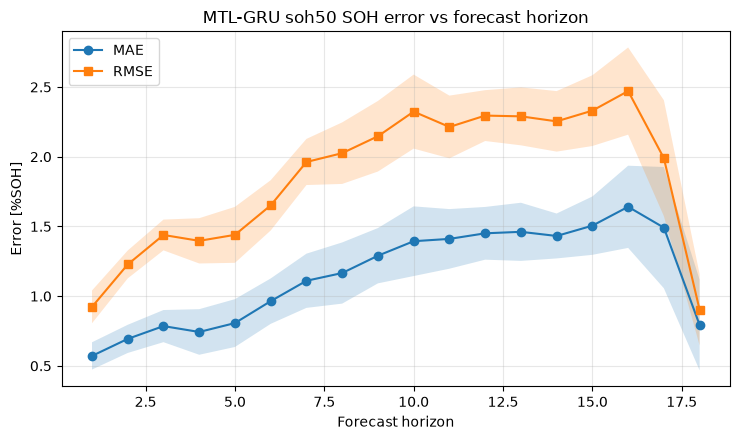

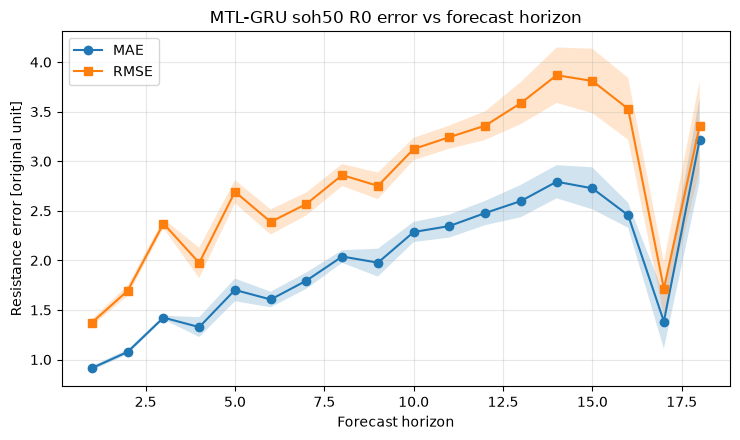

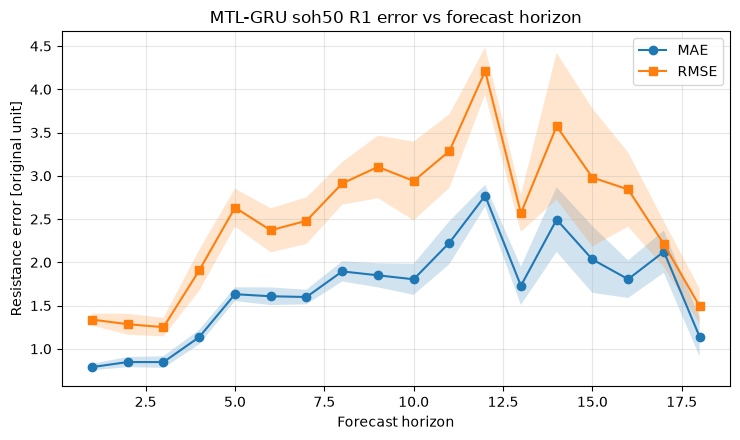

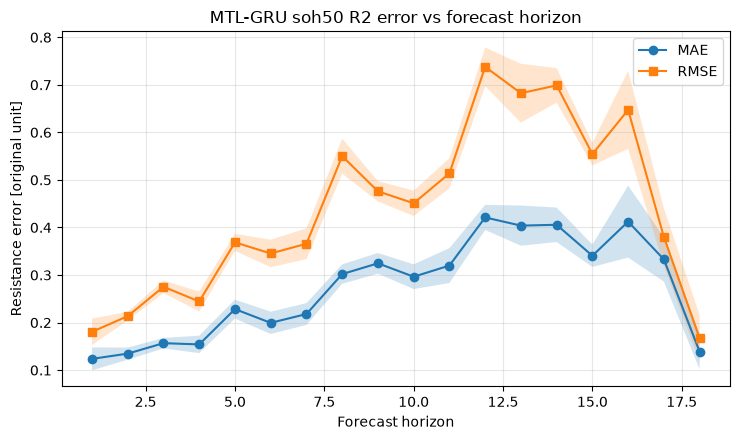

,weight_config,task,horizon,MAE_std_mean,MAE_std_std,RMSE_std_mean,RMSE_std_std,MAE_phys_mean,MAE_phys_std,RMSE_phys_mean,RMSE_phys_std,N_component_min,N_component_max
0,soh50,R0,1,0.1341,0.0034,0.2039,0.0046,0.9139,0.0228,1.3736,0.0356,45,45
1,soh50,R0,2,0.1449,0.0026,0.2178,0.0087,1.0776,0.0244,1.6947,0.0524,44,45
2,soh50,R0,3,0.2042,0.0034,0.3746,0.0065,1.4230,0.0195,2.3716,0.0468,44,45
3,soh50,R0,4,0.1778,0.0148,0.2781,0.0276,1.3272,0.0998,1.9750,0.1535,41,42
4,soh50,R0,5,0.2444,0.0158,0.4686,0.0102,1.7023,0.1144,2.6924,0.1166,41,42
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,soh50,SOH,14,0.1364,0.0153,0.2147,0.0207,1.4315,0.1610,2.2536,0.2170,29,29
68,soh50,SOH,15,0.1434,0.0199,0.2220,0.0242,1.5056,0.2093,2.3305,0.2537,27,27
69,soh50,SOH,16,0.1563,0.0281,0.2354,0.0298,1.6408,0.2947,2.4708,0.3127,24,24
70,soh50,SOH,17,0.1421,0.0414,0.1895,0.0396,1.4913,0.4348,1.9896,0.4158,7,7


In [9]:
# ---- forecast-horizon analysis for FINAL_CONFIG only ----
if FINAL_CONFIG is None:
    horizon_summary = pd.DataFrame()
    print('Horizon analysis skipped because FINAL_CONFIG=None.')

else:
    test_points = points_all[
        points_all['split'] == 'test'
    ].copy()

    component_horizon = (
        test_points
        .groupby(
            ['weight_config', 'seed', 'task', 'component', 'horizon']
        )
        .agg(
            MAE_std=('abs_std', 'mean'),
            RMSE_std=('sq_std', lambda s: math.sqrt(s.mean())),
            MAE_phys=('abs_phys', 'mean'),
            RMSE_phys=('sq_phys', lambda s: math.sqrt(s.mean())),
            N=('yt_std', 'size'),
        )
        .reset_index()
    )

    task_horizon = (
        component_horizon
        .groupby(
            ['weight_config', 'seed', 'task', 'horizon']
        )
        .agg(
            MAE_std=('MAE_std', 'mean'),
            RMSE_std=('RMSE_std', 'mean'),
            MAE_phys=('MAE_phys', 'mean'),
            RMSE_phys=('RMSE_phys', 'mean'),
            N_component_min=('N', 'min'),
            N_component_max=('N', 'max'),
        )
        .reset_index()
    )

    horizon_rows = []
    for (weight_config, task, horizon), d in task_horizon.groupby(
        ['weight_config', 'task', 'horizon'],
        sort=False
    ):
        horizon_rows.append({
            'weight_config': weight_config,
            'task': task,
            'horizon': int(horizon),

            'MAE_std_mean': d['MAE_std'].mean(),
            'MAE_std_std': d['MAE_std'].std(ddof=1),
            'RMSE_std_mean': d['RMSE_std'].mean(),
            'RMSE_std_std': d['RMSE_std'].std(ddof=1),

            'MAE_phys_mean': d['MAE_phys'].mean(),
            'MAE_phys_std': d['MAE_phys'].std(ddof=1),
            'RMSE_phys_mean': d['RMSE_phys'].mean(),
            'RMSE_phys_std': d['RMSE_phys'].std(ddof=1),

            'N_component_min': int(d['N_component_min'].iloc[0]),
            'N_component_max': int(d['N_component_max'].iloc[0]),
        })

    horizon_summary = pd.DataFrame(horizon_rows)

    for task in TASK_ORDER:
        d = horizon_summary[
            horizon_summary['task'] == task
        ].sort_values('horizon')

        if d.empty:
            continue

        plt.figure(figsize=(7.5, 4.5))
        plt.plot(
            d['horizon'],
            d['MAE_phys_mean'],
            marker='o',
            label='MAE'
        )
        plt.fill_between(
            d['horizon'],
            d['MAE_phys_mean'] - d['MAE_phys_std'],
            d['MAE_phys_mean'] + d['MAE_phys_std'],
            alpha=0.2
        )
        plt.plot(
            d['horizon'],
            d['RMSE_phys_mean'],
            marker='s',
            label='RMSE'
        )
        plt.fill_between(
            d['horizon'],
            d['RMSE_phys_mean'] - d['RMSE_phys_std'],
            d['RMSE_phys_mean'] + d['RMSE_phys_std'],
            alpha=0.2
        )

        plt.xlabel('Forecast horizon')
        if task == 'SOH':
            plt.ylabel('Error [%SOH]')
        else:
            plt.ylabel('Resistance error [original unit]')

        plt.title(
            f'MTL-GRU {FINAL_CONFIG} {task} error vs forecast horizon'
        )
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    display(horizon_summary.round(4))

In [10]:
# ---- save Stage B outputs only after FINAL_CONFIG has been frozen ----
if FINAL_CONFIG is None:
    print(
        'No final test files saved because FINAL_CONFIG=None. '
        'Stage A sweep/validation files were already saved.'
    )

else:
    prefix = f'mtl_gru_4task_full200_weighted_{FINAL_CONFIG}'

    points_all.to_csv(
        f'{prefix}_joint_predictions_5seeds.csv',
        index=False
    )
    component_metrics.to_csv(
        f'{prefix}_joint_component_metrics_per_seed.csv',
        index=False
    )
    component_summary.to_csv(
        f'{prefix}_joint_component_metrics_5seed_summary.csv',
        index=False
    )
    task_metrics.to_csv(
        f'{prefix}_joint_task_metrics_per_seed.csv',
        index=False
    )
    task_summary.to_csv(
        f'{prefix}_joint_task_metrics_5seed_summary.csv',
        index=False
    )
    horizon_summary.to_csv(
        f'{prefix}_joint_horizon_5seed_summary.csv',
        index=False
    )

    final_meta = {
        'FINAL_CONFIG': FINAL_CONFIG,
        'weights': WEIGHT_CONFIGS[FINAL_CONFIG],
        'seeds': SEEDS,
        'epochs': EPOCHS,
        'checkpoint_rule': 'minimum weighted validation joint MSE',
        'weight_selection_rule': (
            'validation-only comparison to frozen equal-weight MTL'
        ),
    }
    with open(
        f'{prefix}_experiment_metadata.json',
        'w',
        encoding='utf-8'
    ) as f:
        json.dump(final_meta, f, indent=2)

    print('Saved final weighted-MTL outputs with prefix:')
    print(prefix)
    print('Checkpoint root:', CKPT_ROOT)

Saved final weighted-MTL outputs with prefix:
mtl_gru_4task_full200_weighted_soh50
Checkpoint root: .


## How to run this notebook (SOH50 final test evaluation only)

This notebook is frozen after validation-only weight selection.

Required files in the notebook working directory (or, for the dataset/scaler,
the `/mnt/data/` fallback already supported by the code):

```text
SOH 50 evaluation/
├── mtl_gru_4task_full200_soh50_final_test_eval_fixed_v4.ipynb
├── seq_dataset_10dim_v7.npz
├── scaler_10dim_v7.json
├── seed_42_best_joint.pt
├── seed_43_best_joint.pt
├── seed_44_best_joint.pt
├── seed_45_best_joint.pt
└── seed_46_best_joint.pt
```

Run with:

```python
RUN_SWEEP = False
FINAL_CONFIG = 'soh50'
```

The notebook loads the frozen SOH50 best-joint checkpoints and evaluates the
untouched validation/test splits. No further task-weight selection is performed
using test results.


# Final evaluation note

This notebook is frozen for the SOH50 task-weight configuration.
The model configuration was selected using validation-only weight comparison;
test results are generated only after this selection step.
